In [ ]:
!pip install galaxy-datasets

In [9]:
from pathlib import Path
from galaxy_datasets.pytorch import GZ2

data_root = Path("./data")

try:
    dataset = GZ2(root=str(data_root), train=True, download=False)
    print(f"Dataset found locally: {len(dataset)} galaxies!")
except Exception:
    dataset = GZ2(root=str(data_root), train=True, download=True)
    print(f"Downloaded and loaded {len(dataset)} galaxies!")

Dataset found locally: 167434 galaxies!


In [10]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from galaxy_datasets.pytorch import GZ2
# Define two separate transforms
train_transforms = transforms.Compose([
    transforms.CenterCrop(300),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(degrees=90),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.CenterCrop(300),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset WITHOUT transforms
dataset = GZ2(root='./data', train=True, download=False, transform=None)

from torch.utils.data import random_split

# Load dataset twice with different transforms
train_dataset = GZ2(root='./data', train=True, download=False, transform=train_transforms)
val_dataset = GZ2(root='./data', train=True, download=False, transform=val_transforms)

# Split using same seed so they're identical splits
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(train_dataset), generator=generator).tolist()  # ← .tolist()

train_indices = indices[:16000]
val_indices = indices[16000:36000]  # 20000 val samples

train_subset = torch.utils.data.Subset(train_dataset, train_indices)
val_subset = torch.utils.data.Subset(val_dataset, val_indices)
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
print(f"Training on {len(train_subset):,} images")
print(f"Validating on {len(val_subset):,} images")


Training on 16,000 images
Validating on 20,000 images


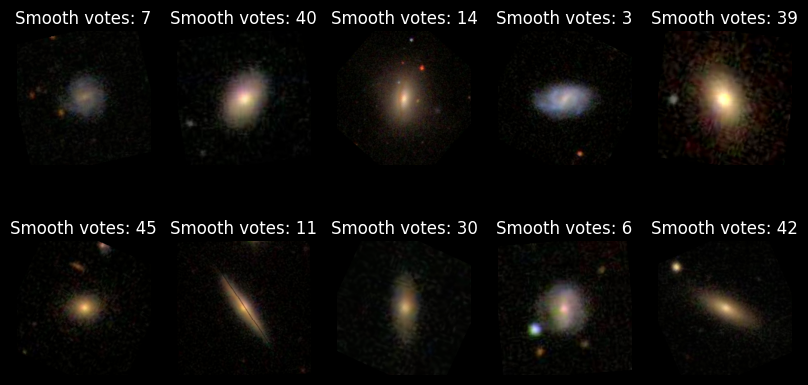

Shape of one image tensor: torch.Size([3, 224, 224])


In [48]:
import matplotlib.pyplot as plt
import numpy as np

data_iter = iter(train_loader)
batch_data = next(data_iter)

images = batch_data['image']
labels_smooth = batch_data['smooth-or-featured-gz2_smooth']

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = images[i]
    img = np.transpose(img.numpy(), (1, 2, 0))
    img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

    ax.imshow(img)
    ax.set_title(f"Smooth votes: {labels_smooth[i].item()}")
    ax.axis("off")

plt.show()

print("Shape of one image tensor:", images[0].shape)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class GalaxyResNet(nn.Module):
    def __init__(self, num_classes=3):
        super(GalaxyResNet, self).__init__()
        
        # Load pretrained ResNet18
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Freeze early layers, fine-tune from layer3 onwards
        for name, param in self.backbone.named_parameters():
            if 'layer1' in name or 'layer2' in name:
                param.requires_grad = False
        
        # Replace final classifier
        in_features = self.backbone.fc.in_features  # 512
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

# Test output shape
test_input = torch.randn(4, 3, 224, 224)
model = GalaxyResNet()
print("Output shape:", model(test_input).shape)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Output shape: torch.Size([4, 3])
Total parameters: 11,178,051
Trainable parameters: 10,504,515


✓ Training on GPU: NVIDIA GeForce RTX 3060 Laptop GPU
  CUDA Version: 12.6
  GPU Memory: 6.44 GB

Starting training on cuda...
Model parameters: 11,178,051
Epoch [1/20] | Train: 0.1264 | Val: 0.0656
scheduler update: [0.0003]
  → Saved best model (val_loss: 0.0656)
Epoch [2/20] | Train: 0.0740 | Val: 0.0606
scheduler update: [0.0003]
  → Saved best model (val_loss: 0.0606)
Epoch [3/20] | Train: 0.0656 | Val: 0.0605
scheduler update: [0.0003]
  → Saved best model (val_loss: 0.0605)
Epoch [4/20] | Train: 0.0597 | Val: 0.0577
scheduler update: [0.0003]
  → Saved best model (val_loss: 0.0577)
Epoch [5/20] | Train: 0.0568 | Val: 0.0480
scheduler update: [0.0003]
  → Saved best model (val_loss: 0.0480)
Epoch [6/20] | Train: 0.0542 | Val: 0.0492
scheduler update: [0.0003]
Epoch [7/20] | Train: 0.0523 | Val: 0.0460
scheduler update: [0.0003]
  → Saved best model (val_loss: 0.0460)
Epoch [8/20] | Train: 0.0510 | Val: 0.0536
scheduler update: [0.0003]
Epoch [9/20] | Train: 0.0490 | Val: 0.0512
s

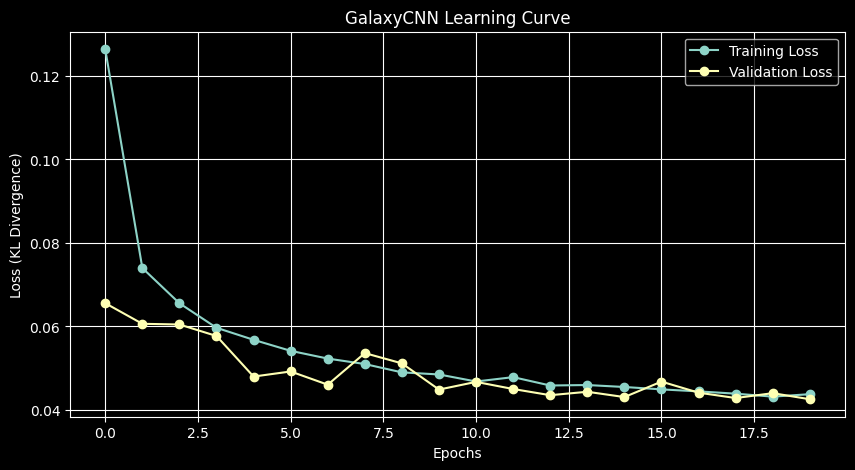

Learning curve saved to ./plots/learning_curve.png


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
from datetime import datetime

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 3e-4
num_epochs = 20  # More epochs to see progression

# CUDA optimization
if torch.cuda.is_available():
    print(f"✓ Training on GPU: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    # Enable CUDA optimizations
    torch.backends.cudnn.benchmark = True
else:
    print(" WARNING: CUDA not available. Training on CPU will be slow.")

model = GalaxyResNet(num_classes=3).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.KLDivLoss(reduction='batchmean')

train_history = []
val_history = []
best_val_loss = float('inf')

print(f"\nStarting training on {device}...")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

patience_counter = 0
early_stop_patience = 5

for epoch in range(num_epochs):
    # Training
    model.train()
    running_train_loss = 0.0

    for batch in train_loader:
        inputs = batch['image'].to(device, non_blocking=True)

        targets = torch.stack([
            batch['smooth-or-featured-gz2_smooth'],
            batch['smooth-or-featured-gz2_featured-or-disk'],
            batch['smooth-or-featured-gz2_artifact']
        ], dim=1).float().to(device, non_blocking=True)

        targets = targets / (targets.sum(dim=1, keepdim=True) + 1e-6)

        optimizer.zero_grad()
        outputs = model(inputs)
        log_probs = F.log_softmax(outputs, dim=1)
        loss = criterion(log_probs, targets)   # criterion is KLDivLoss(reduction='batchmean')
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_history.append(avg_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            inputs = batch['image'].to(device, non_blocking=True)

            targets = torch.stack([
                batch['smooth-or-featured-gz2_smooth'],
                batch['smooth-or-featured-gz2_featured-or-disk'],
                batch['smooth-or-featured-gz2_artifact']
            ], dim=1).float().to(device, non_blocking=True)

            targets = targets / (targets.sum(dim=1, keepdim=True) + 1e-6)

            outputs = model(inputs)
            log_probs = F.log_softmax(outputs, dim=1)
            loss = criterion(log_probs, targets)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    scheduler.step(avg_val_loss)
    val_history.append(avg_val_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")
    print(f"scheduler update: {scheduler.get_last_lr()}")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0

        os.makedirs('./models', exist_ok=True)
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
        }, './models/best_model.pth')
        print(f"  → Saved best model (val_loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
    if patience_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break
print("\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")

# Save final model
torch.save({
    'model_state_dict': model.state_dict(),
    'train_history': train_history,
    'val_history': val_history,
}, './models/final_model.pth')



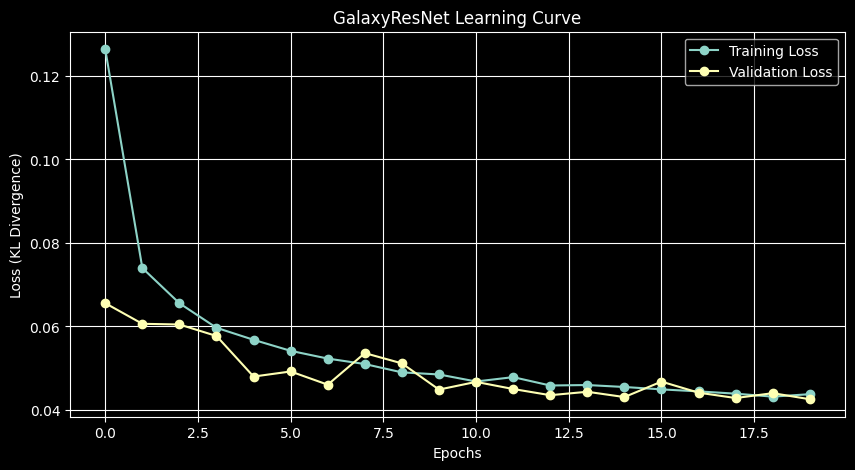

Learning curve saved to ./plots/learning_curve.png


In [16]:
# Plot and save learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_history, label='Training Loss', marker='o')
plt.plot(val_history, label='Validation Loss', marker='o')
plt.title('GalaxyResNet Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (KL Divergence)')
plt.legend()
plt.grid(True)
os.makedirs('./plots', exist_ok=True)
plt.savefig('./plots/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Learning curve saved to ./plots/learning_curve.png")

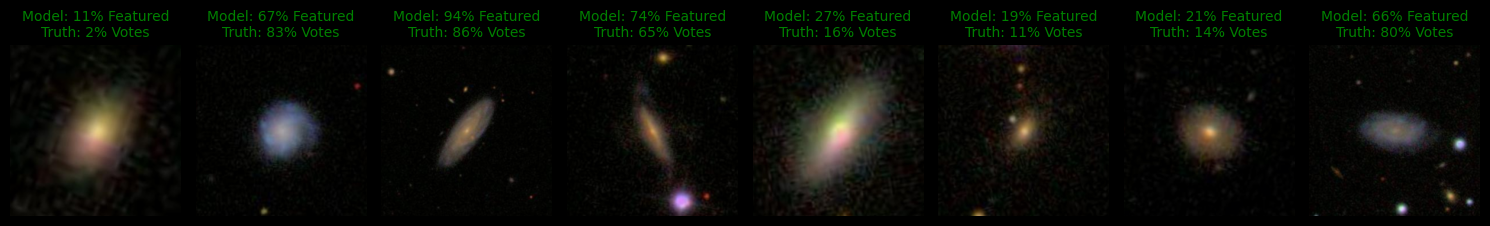

Predictions visualization saved to ./plots/predictions.png


In [41]:
def visualize_predictions(model, loader, num_images=8):
    model.eval()

    batch = next(iter(loader))
    inputs = batch['image'].to(device)

    raw_smooth = batch['smooth-or-featured-gz2_smooth']
    raw_featured = batch['smooth-or-featured-gz2_featured-or-disk']
    raw_artifact = batch['smooth-or-featured-gz2_artifact']

    all_votes = torch.stack([raw_smooth, raw_featured, raw_artifact], dim=1)
    total_votes = all_votes.sum(dim=1)
    true_featured_prob = raw_featured / (total_votes + 1e-6)

    with torch.no_grad():
        outputs = model(inputs)
        probs = torch.exp(F.log_softmax(outputs, dim=1))

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        ax = axes[i]

        # Unnormalize for display
        img = inputs[i].cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        ax.imshow(img)
        ax.axis('off')

        p_feat = probs[i][1].item()
        t_feat = true_featured_prob[i].item()

        ax.set_title(f"Model: {p_feat:.0%} Featured\nTruth: {t_feat:.0%} Votes",
                     fontsize=10,
                     color='green' if abs(p_feat - t_feat) < 0.2 else 'red')

    plt.tight_layout()
    os.makedirs('./plots', exist_ok=True)
    plt.savefig('./plots/predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Predictions visualization saved to ./plots/predictions.png")

visualize_predictions(model, val_loader)

## Additional Performance Metrics

Detailed analysis of model predictions vs ground truth

Evaluating model performance...


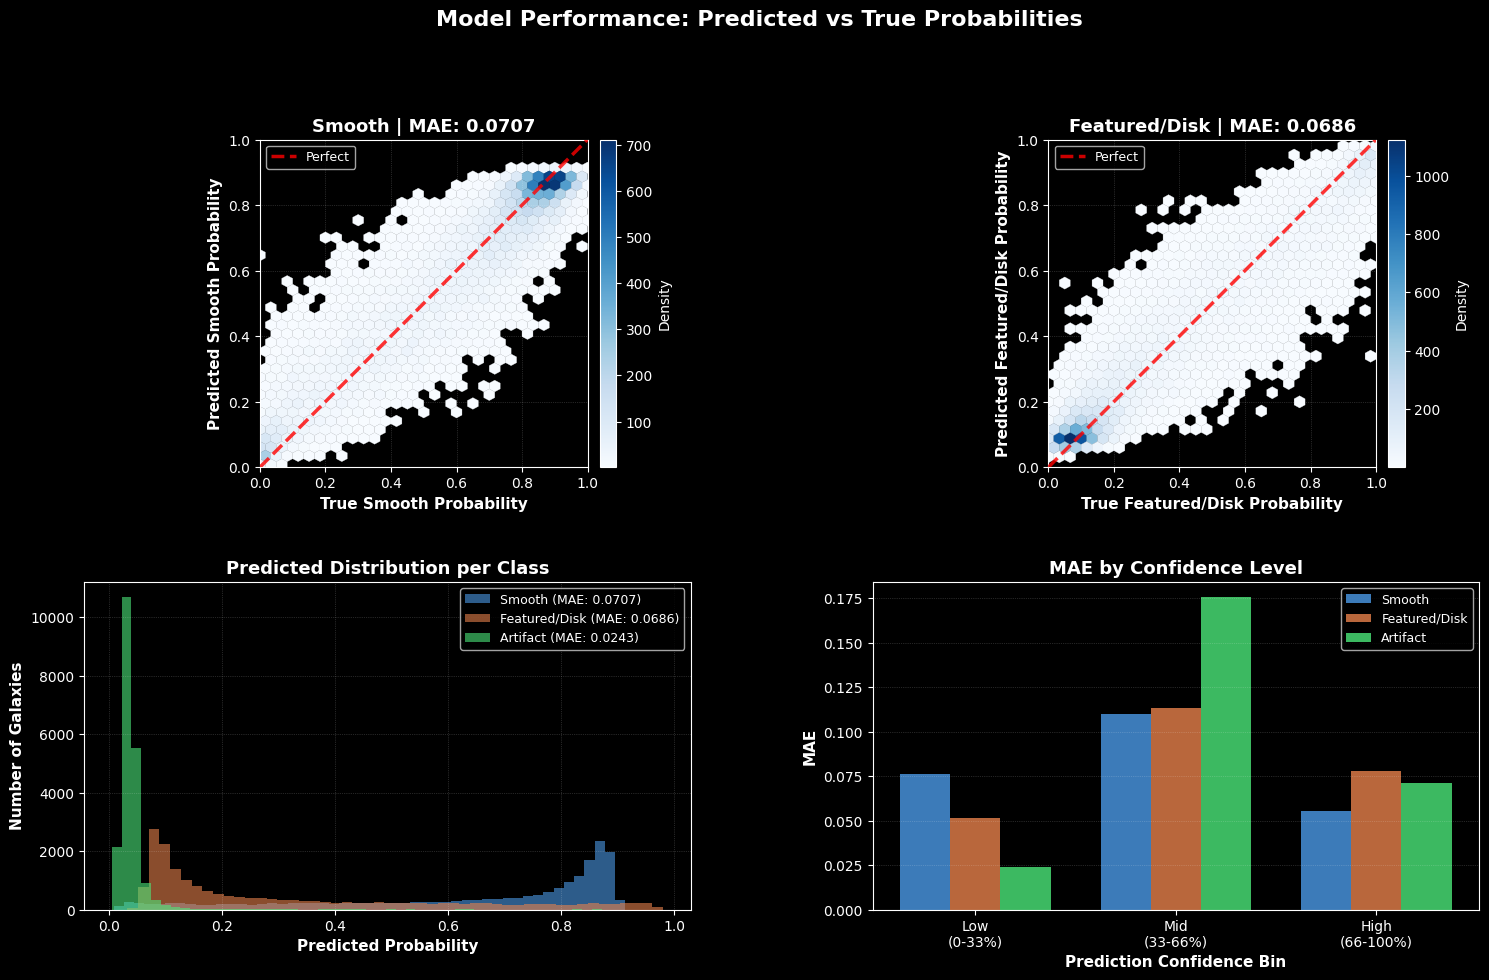


PER-CLASS PERFORMANCE METRICS
Smooth              : MAE = 0.0707
Featured/Disk       : MAE = 0.0686
Artifact            : MAE = 0.0243

Featured/Disk Correlation: 0.948


In [42]:
from sklearn.metrics import mean_absolute_error
from sklearn.calibration import calibration_curve
from matplotlib.gridspec import GridSpec
import numpy as np

# Calculate detailed performance metrics
model.eval()
all_predictions = []
all_targets = []

print("Evaluating model performance...")
with torch.no_grad():
    for batch in val_loader:
        inputs = batch['image'].to(device)

        targets = torch.stack([
            batch['smooth-or-featured-gz2_smooth'],
            batch['smooth-or-featured-gz2_featured-or-disk'],
            batch['smooth-or-featured-gz2_artifact']
        ], dim=1).float()

        targets = targets / (targets.sum(dim=1, keepdim=True) + 1e-6)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu()

        all_predictions.append(probs)
        all_targets.append(targets)

all_predictions = torch.cat(all_predictions, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

class_names = ['Smooth', 'Featured/Disk', 'Artifact']
mae_per_class = [mean_absolute_error(all_targets[:, i], all_predictions[:, i]) for i in range(3)]
colors = ['#4C9BE8', '#E8824C', '#4CE87A']

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# --- Plot 1: Hexbin Smooth ---
ax1 = fig.add_subplot(gs[0, 0])
hb = ax1.hexbin(all_targets[:, 0], all_predictions[:, 0],
                gridsize=30, cmap='Blues', mincnt=1,
                edgecolors='face', linewidths=0.2)
plt.colorbar(hb, ax=ax1, label='Density', pad=0.02)
ax1.plot([0, 1], [0, 1], 'r--', linewidth=2.5, label='Perfect', zorder=10, alpha=0.8)
ax1.set_xlabel('True Smooth Probability', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted Smooth Probability', fontsize=11, fontweight='bold')
ax1.set_title(f'Smooth | MAE: {mae_per_class[0]:.4f}', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.set_aspect('equal')
ax1.grid(alpha=0.3, linestyle=':', linewidth=0.5)
ax1.legend(loc='upper left', fontsize=9)

# --- Plot 2: Hexbin Featured/Disk ---
ax2 = fig.add_subplot(gs[0, 1])
hb2 = ax2.hexbin(all_targets[:, 1], all_predictions[:, 1],
                 gridsize=30, cmap='Blues', mincnt=1,
                 edgecolors='face', linewidths=0.2)
plt.colorbar(hb2, ax=ax2, label='Density', pad=0.02)
ax2.plot([0, 1], [0, 1], 'r--', linewidth=2.5, label='Perfect', zorder=10, alpha=0.8)
ax2.set_xlabel('True Featured/Disk Probability', fontsize=11, fontweight='bold')
ax2.set_ylabel('Predicted Featured/Disk Probability', fontsize=11, fontweight='bold')
ax2.set_title(f'Featured/Disk | MAE: {mae_per_class[1]:.4f}', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.set_aspect('equal')
ax2.grid(alpha=0.3, linestyle=':', linewidth=0.5)
ax2.legend(loc='upper left', fontsize=9)

# --- Plot 3: Predicted distribution ---
ax3 = fig.add_subplot(gs[1, 0])
for i, (name, color) in enumerate(zip(class_names, colors)):
    ax3.hist(all_predictions[:, i], bins=50, alpha=0.6,
             label=f'{name} (MAE: {mae_per_class[i]:.4f})',
             color=color, edgecolor='none')
ax3.set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of Galaxies', fontsize=11, fontweight='bold')
ax3.set_title('Predicted Distribution per Class', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3, linestyle=':', linewidth=0.5)

# --- Plot 4: Confidence-stratified MAE ---
ax4 = fig.add_subplot(gs[1, 1])
bins = [(0.0, 0.33), (0.33, 0.66), (0.66, 1.01)]
bin_labels = ['Low\n(0-33%)', 'Mid\n(33-66%)', 'High\n(66-100%)']
x = np.arange(len(bin_labels))
width = 0.25

for i, (name, color) in enumerate(zip(class_names, colors)):
    mae_bins = []
    for low, high in bins:
        mask = (all_predictions[:, i] >= low) & (all_predictions[:, i] < high)
        if mask.sum() > 0:
            mae_bins.append(mean_absolute_error(all_targets[mask, i], all_predictions[mask, i]))
        else:
            mae_bins.append(0)
    ax4.bar(x + i * width, mae_bins, width, label=name, color=color, alpha=0.8, edgecolor='none')

ax4.set_xlabel('Prediction Confidence Bin', fontsize=11, fontweight='bold')
ax4.set_ylabel('MAE', fontsize=11, fontweight='bold')
ax4.set_title('MAE by Confidence Level', fontsize=13, fontweight='bold')
ax4.set_xticks(x + width)
ax4.set_xticklabels(bin_labels, fontsize=10)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3, linestyle=':', linewidth=0.5, axis='y')

plt.suptitle('Model Performance: Predicted vs True Probabilities',
             fontsize=16, fontweight='bold', y=1.01)

os.makedirs('./plots', exist_ok=True)
plt.savefig('./plots/prediction_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("PER-CLASS PERFORMANCE METRICS")
print("="*60)
for name, mae in zip(class_names, mae_per_class):
    print(f"{name:20s}: MAE = {mae:.4f}")
print(f"\nFeatured/Disk Correlation: {np.corrcoef(all_targets[:, 1], all_predictions[:, 1])[0,1]:.3f}")
print("="*60)

## Training Summary

Complete overview of model configuration and performance

In [44]:
print("\n" + "="*70)
print(" "*15 + "GALAXY ZOO 2 CLASSIFICATION")
print(" "*20 + "TRAINING SUMMARY")
print("="*70)

print("\n MODEL ARCHITECTURE")
print("-"*70)
print(f"  Model Type:              GalaxyResNet (ResNet18 pretrained)")
print(f"  Total Parameters:        {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable Parameters:    {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  Frozen Layers:           layer1, layer2 (ImageNet features)")

print("\n DATASET")
print("-"*70)
print(f"  Total Galaxies:          {len(dataset):,}")
print(f"  Training Samples:        {len(train_subset):,}")
print(f"  Validation Samples:      {len(val_subset):,}")
print(f"  Image Size:              224×224 RGB")
print(f"  Augmentation:            Flip H/V, Rotation ±90°")

print("\n TRAINING CONFIGURATION")
print("-"*70)
print(f"  Epochs Run:              {len(train_history)}")
print(f"  Batch Size:              64")
print(f"  Initial Learning Rate:   {learning_rate}")
print(f"  Final Learning Rate:     {scheduler.get_last_lr()[0]}")
print(f"  Optimizer:               Adam")
print(f"  Loss Function:           KL Divergence (batchmean)")
print(f"  Scheduler:               ReduceLROnPlateau (patience=2, factor=0.5)")

print("\n PERFORMANCE METRICS")
print("-"*70)
print(f"  Best Validation Loss:    {best_val_loss:.4f}")
print(f"  Final Training Loss:     {train_history[-1]:.4f}")
print(f"  Smooth MAE:              {mae_per_class[0]:.4f}")
print(f"  Featured/Disk MAE:       {mae_per_class[1]:.4f}")
print(f"  Artifact MAE:            {mae_per_class[2]:.4f}")
print(f"  Featured/Disk Corr:      {np.corrcoef(all_targets[:, 1], all_predictions[:, 1])[0,1]:.3f}")

print("\n HARDWARE")
print("-"*70)
print(f"  Device:                  {device}")
if torch.cuda.is_available():
    print(f"  GPU:                     {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version:            {torch.version.cuda}")
    print(f"  GPU Memory:              {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("\n OUTPUT FILES")
print("-"*70)
print("  Models:")
print("    ├─ models/best_model.pth")
print("    └─ models/final_model.pth")
print("  Visualizations:")
print("    ├─ plots/learning_curve.png")
print("    ├─ plots/predictions.png")
print("    └─ plots/prediction_scatter.png")

print("\n" + "="*70)
print("✓ Training completed successfully")
print("="*70)


               GALAXY ZOO 2 CLASSIFICATION
                    TRAINING SUMMARY

 MODEL ARCHITECTURE
----------------------------------------------------------------------
  Model Type:              GalaxyResNet (ResNet18 pretrained)
  Total Parameters:        11,178,051
  Trainable Parameters:    10,504,515
  Frozen Layers:           layer1, layer2 (ImageNet features)

 DATASET
----------------------------------------------------------------------
  Total Galaxies:          167,434
  Training Samples:        16,000
  Validation Samples:      20,000
  Image Size:              224×224 RGB
  Augmentation:            Flip H/V, Rotation ±90°

 TRAINING CONFIGURATION
----------------------------------------------------------------------
  Epochs Run:              20
  Batch Size:              64
  Initial Learning Rate:   0.0003
  Final Learning Rate:     0.0003
  Optimizer:               Adam
  Loss Function:           KL Divergence (batchmean)
  Scheduler:               ReduceLROnPlateau